### Data Splitting

In [1]:
# Import liabraries
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
# Path 
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT /
    "data" /
    "processed"
)

FIGURES_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLEAN_METADATA_PATH = (
    PROCESSED_DATA_DIR /
    "HAM10000_metadata_clean.csv"
)

print("Project root:", PROJECT_ROOT)
print("Clean metadata:", CLEAN_METADATA_PATH)

Project root: c:\Deep Learning\skin-lesion-classification
Clean metadata: c:\Deep Learning\skin-lesion-classification\data\processed\HAM10000_metadata_clean.csv


In [3]:
# Import splitting function
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.splitting import (
    build_lesion_table,
    check_lesion_label_consistency,
    stratified_lesion_split,
    check_lesion_leakage,
    validate_split_integrity,
    get_split_summary,
    get_class_distribution,
    combine_splits,
    save_splits,
)

In [4]:
# Import clean metadata
df = pd.read_csv(
    CLEAN_METADATA_PATH
)

print(
    "Dataset shape:",
    df.shape
)

df.head()

Dataset shape: (10015, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data/raw/HAM10000_images_part_2/ISIC_0031633.jpg


In [5]:
# Check required columns
required_columns = [
    "lesion_id",
    "image_id",
    "dx",
]

for column in required_columns:

    print(
        f"{column:<12}",
        column in df.columns
    )

lesion_id    True
image_id     True
dx           True


In [6]:
# Data set before splitting
print("=" * 60)
print("DATASET BEFORE SPLITTING")
print("=" * 60)

print(
    f"Number of images  : {len(df):,}"
)

print(
    f"Number of lesions : "
    f"{df['lesion_id'].nunique():,}"
)

print(
    f"Number of classes : "
    f"{df['dx'].nunique()}"
)

DATASET BEFORE SPLITTING
Number of images  : 10,015
Number of lesions : 7,470
Number of classes : 7


In [7]:
# Check lesion label consistency
inconsistent_lesions = (
    check_lesion_label_consistency(df)
)

print(
    "Lesions with multiple diagnosis labels:",
    len(inconsistent_lesions)
)

if not inconsistent_lesions.empty:
    display(inconsistent_lesions.head(20))

Lesions with multiple diagnosis labels: 0


In [8]:
# Build lesion-level table
lesion_df = build_lesion_table(df)

print(
    "Image-level records:",
    len(df)
)

print(
    "Lesion-level records:",
    len(lesion_df)
)

lesion_df.head()

Image-level records: 10015
Lesion-level records: 7470


,lesion_id,dx,num_images
0,HAM_0000000,nv,2
1,HAM_0000001,bkl,1
2,HAM_0000002,mel,3
3,HAM_0000003,nv,1
4,HAM_0000004,nv,1


In [9]:
# Image per lesion 
lesion_df["num_images"].describe()

count    7470.000000
mean        1.340696
std         0.633970
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: num_images, dtype: float64

In [10]:
lesion_df["num_images"].value_counts().sort_index()

num_images
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64

In [11]:
# Diagnosis distribution at lesion level
lesion_class_distribution = (
    lesion_df["dx"]
    .value_counts()
    .sort_values(ascending=False)
)

lesion_class_distribution

dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64

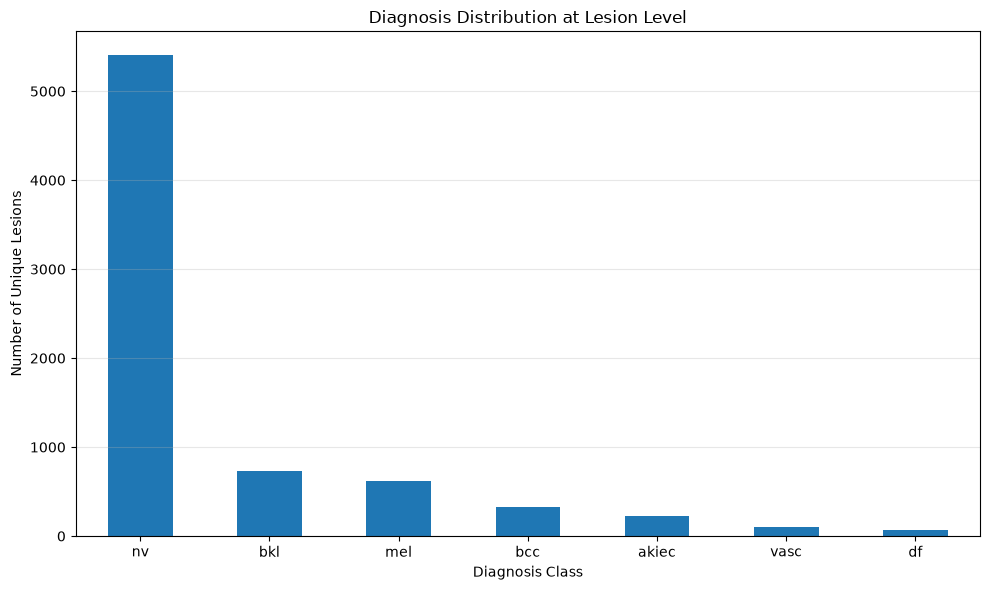

In [12]:
# Visualize lesion-level class distribution
plt.figure(figsize=(10, 6))

lesion_class_distribution.plot(
    kind="bar"
)

plt.title(
    "Diagnosis Distribution at Lesion Level"
)

plt.xlabel(
    "Diagnosis Class"
)

plt.ylabel(
    "Number of Unique Lesions"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [13]:
# Define split configuration
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

RANDOM_STATE = 42

print(
    f"Train      : {TRAIN_SIZE:.0%}"
)

print(
    f"Validation : {VAL_SIZE:.0%}"
)

print(
    f"Test       : {TEST_SIZE:.0%}"
)

Train      : 70%
Validation : 15%
Test       : 15%


In [14]:
# Perform stratified lesion-level split
train_df, val_df, test_df = (
    stratified_lesion_split(
        df=df,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
)

In [15]:
# Basic split size 
print("=" * 60)
print("SPLIT RESULTS")
print("=" * 60)

print(
    f"Train images : {len(train_df):,}"
)

print(
    f"Val images   : {len(val_df):,}"
)

print(
    f"Test images  : {len(test_df):,}"
)

print(
    "\nTotal:",
    len(train_df)
    + len(val_df)
    + len(test_df)
)

SPLIT RESULTS
Train images : 6,981
Val images   : 1,532
Test images  : 1,502

Total: 10015


In [16]:
# Split summary
split_summary = get_split_summary(
    train_df,
    val_df,
    test_df,
)

split_summary

,split,num_images,num_lesions,percentage_images
0,train,6981,5229,69.705442
1,val,1532,1120,15.297054
2,test,1502,1121,14.997504


In [17]:
# Check lesion leakage
lesion_leakage = (
    check_lesion_leakage(
        train_df,
        val_df,
        test_df,
    )
)

for pair, overlapping_lesions in lesion_leakage.items():

    print(
        f"{pair:<15}: "
        f"{len(overlapping_lesions)} overlapping lesions"
    )

train_val      : 0 overlapping lesions
train_test     : 0 overlapping lesions
val_test       : 0 overlapping lesions


In [18]:
# Full integrity validation
integrity_report = (
    validate_split_integrity(
        original_df=df,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
    )
)

In [19]:
print("=" * 70)
print("SPLIT INTEGRITY REPORT")
print("=" * 70)

print(
    "Original images      :",
    integrity_report["original_images"]
)

print(
    "Train images         :",
    integrity_report["train_images"]
)

print(
    "Validation images    :",
    integrity_report["val_images"]
)

print(
    "Test images          :",
    integrity_report["test_images"]
)

print(
    "Total after split    :",
    integrity_report["total_after_split"]
)

print(
    "\nAll images preserved :",
    integrity_report["all_images_preserved"]
)

print(
    "Same image set       :",
    integrity_report["same_image_set"]
)

print(
    "No lesion leakage    :",
    integrity_report["no_lesion_leakage"]
)

print(
    "No image leakage     :",
    integrity_report["no_image_leakage"]
)

SPLIT INTEGRITY REPORT
Original images      : 10015
Train images         : 6981
Validation images    : 1532
Test images          : 1502
Total after split    : 10015

All images preserved : True
Same image set       : True
No lesion leakage    : True
No image leakage     : True


In [20]:
# Assert split integrity --> All images preserved
assert integrity_report["all_images_preserved"], (
    "Some images were lost during splitting."
)

assert integrity_report["same_image_set"], (
    "Split image IDs do not match original image IDs."
)

assert integrity_report["no_lesion_leakage"], (
    "Lesion leakage detected between splits."
)

assert integrity_report["no_image_leakage"], (
    "Image leakage detected between splits."
)

print(
    "All split integrity checks passed."
)

All split integrity checks passed.


### Class distribution after split

In [21]:
train_distribution = (
    get_class_distribution(train_df)
)

val_distribution = (
    get_class_distribution(val_df)
)

test_distribution = (
    get_class_distribution(test_df)
)

In [22]:
# Train distribution
print("TRAIN")
display(train_distribution)

TRAIN


,count,percentage
dx,,
akiec,222,3.180060
bcc,361,5.171179
bkl,772,11.058588
df,71,1.017046
mel,773,11.072912
nv,4683,67.082080
vasc,99,1.418135


In [23]:
# Validation distribution
print("VALIDATION")
display(val_distribution)

VALIDATION


,count,percentage
dx,,
akiec,53,3.459530
bcc,82,5.352480
bkl,160,10.443864
df,24,1.566580
mel,173,11.292428
nv,1018,66.449086
vasc,22,1.436031


In [24]:
# Test dissribution
print("TEST")
display(test_distribution)

TEST


,count,percentage
dx,,
akiec,52,3.462051
bcc,71,4.727031
bkl,167,11.118509
df,20,1.331558
mel,167,11.118509
nv,1004,66.844208
vasc,21,1.398136


In [25]:
# Compare class distributions across splits
full_percentage = (
    df["dx"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

train_percentage = (
    train_df["dx"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

val_percentage = (
    val_df["dx"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

test_percentage = (
    test_df["dx"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

distribution_comparison = pd.DataFrame({
    "full_dataset": full_percentage,
    "train": train_percentage,
    "validation": val_percentage,
    "test": test_percentage,
})

distribution_comparison.round(2)

,full_dataset,train,validation,test
dx,,,,
akiec,3.27,3.18,3.46,3.46
bcc,5.13,5.17,5.35,4.73
bkl,10.97,11.06,10.44,11.12
df,1.15,1.02,1.57,1.33
mel,11.11,11.07,11.29,11.12
nv,66.95,67.08,66.45,66.84
vasc,1.42,1.42,1.44,1.40


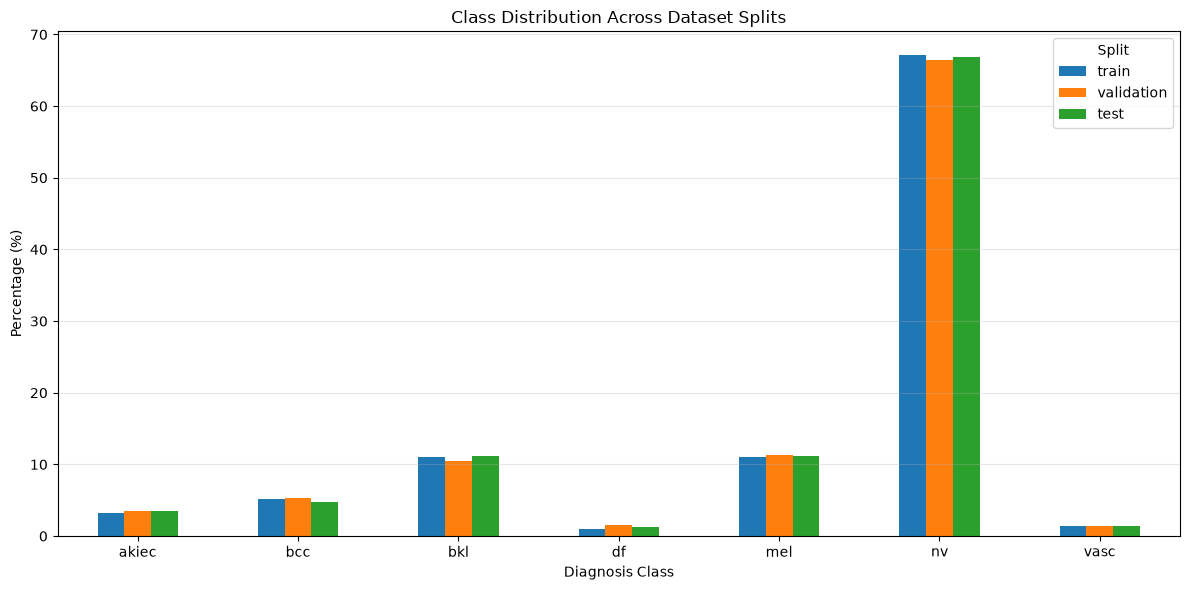

In [26]:
# Visualize lesion-level class distribution
plot_df = distribution_comparison[
    [
        "train",
        "validation",
        "test",
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.title(
    "Class Distribution Across Dataset Splits"
)

plt.xlabel(
    "Diagnosis Class"
)

plt.ylabel(
    "Percentage (%)"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Split"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "split_class_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [27]:
# Checking for every class in every split
all_classes = set(
    df["dx"].unique()
)

for split_name, split_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    split_classes = set(
        split_df["dx"].unique()
    )

    missing_classes = (
        all_classes - split_classes
    )

    print(
        f"{split_name:<12} "
        f"classes: {len(split_classes)}"
    )

    print(
        "Missing:",
        missing_classes
        if missing_classes
        else "None"
    )

    print()

train        classes: 7
Missing: None

validation   classes: 7
Missing: None

test         classes: 7
Missing: None



In [28]:
# Actual split percentages
total_images = len(df)

actual_train_pct = (
    len(train_df)
    / total_images
    * 100
)

actual_val_pct = (
    len(val_df)
    / total_images
    * 100
)

actual_test_pct = (
    len(test_df)
    / total_images
    * 100
)

print(
    f"Actual Train      : "
    f"{actual_train_pct:.2f}%"
)

print(
    f"Actual Validation : "
    f"{actual_val_pct:.2f}%"
)

print(
    f"Actual Test       : "
    f"{actual_test_pct:.2f}%"
)

Actual Train      : 69.71%
Actual Validation : 15.30%
Actual Test       : 15.00%


In [29]:
# Reproducibility check
train_df_2, val_df_2, test_df_2 = (
    stratified_lesion_split(
        df=df,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
)

assert set(train_df["image_id"]) == set(
    train_df_2["image_id"]
)

assert set(val_df["image_id"]) == set(
    val_df_2["image_id"]
)

assert set(test_df["image_id"]) == set(
    test_df_2["image_id"]
)

print(
    "Split is reproducible with random_state =",
    RANDOM_STATE,
)

Split is reproducible with random_state = 42


In [30]:
# Save individual splits
save_splits(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    output_dir=PROCESSED_DATA_DIR,
)

print(
    "Split files saved to:",
    PROCESSED_DATA_DIR,
)

Split files saved to: c:\Deep Learning\skin-lesion-classification\data\processed


In [31]:
# Inspect saved files
saved_train_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "train.csv"
)

saved_train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,split
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0027419.jpg,train
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0025030.jpg,train
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0026769.jpg,train
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0025661.jpg,train
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data/raw/HAM10000_images_part_2/ISIC_0031633.jpg,train


In [32]:
# Inspect combined splits
split_df = pd.read_csv(
    PROCESSED_DATA_DIR /
    "HAM10000_metadata_split.csv"
)

split_df[
    [
        "image_id",
        "lesion_id",
        "dx",
        "split",
    ]
].head(10)

,image_id,lesion_id,dx,split
0,ISIC_0027419,HAM_0000118,bkl,train
1,ISIC_0025030,HAM_0000118,bkl,train
2,ISIC_0026769,HAM_0002730,bkl,train
3,ISIC_0025661,HAM_0002730,bkl,train
4,ISIC_0031633,HAM_0001466,bkl,train
5,ISIC_0027850,HAM_0001466,bkl,train
6,ISIC_0025276,HAM_0001396,bkl,train
7,ISIC_0029396,HAM_0004234,bkl,train
8,ISIC_0025984,HAM_0004234,bkl,train
9,ISIC_0031326,HAM_0007207,bkl,train


In [33]:
# Combined split count 
split_df["split"].value_counts()

split
train    6981
val      1532
test     1502
Name: count, dtype: int64

In [34]:
# Split summary
print("=" * 70)
print("HAM10000 DATA SPLIT SUMMARY")
print("=" * 70)

print(f"""
Split strategy:
    Lesion-level stratified splitting

Target:
    dx

Group identifier:
    lesion_id

Random seed:
    {RANDOM_STATE}

Requested ratio:
    Train      : {TRAIN_SIZE:.0%}
    Validation : {VAL_SIZE:.0%}
    Test       : {TEST_SIZE:.0%}

Actual image ratio:
    Train      : {actual_train_pct:.2f}%
    Validation : {actual_val_pct:.2f}%
    Test       : {actual_test_pct:.2f}%

Number of images:
    Train      : {len(train_df):,}
    Validation : {len(val_df):,}
    Test       : {len(test_df):,}

Number of unique lesions:
    Train      : {train_df['lesion_id'].nunique():,}
    Validation : {val_df['lesion_id'].nunique():,}
    Test       : {test_df['lesion_id'].nunique():,}

Integrity checks:
    All images preserved : {integrity_report['all_images_preserved']}
    Same image set       : {integrity_report['same_image_set']}
    No lesion leakage    : {integrity_report['no_lesion_leakage']}
    No image leakage     : {integrity_report['no_image_leakage']}

Important:
    All images belonging to the same lesion are assigned
    to exactly one dataset split.
""")

HAM10000 DATA SPLIT SUMMARY

Split strategy:
    Lesion-level stratified splitting

Target:
    dx

Group identifier:
    lesion_id

Random seed:
    42

Requested ratio:
    Train      : 70%
    Validation : 15%
    Test       : 15%

Actual image ratio:
    Train      : 69.71%
    Validation : 15.30%
    Test       : 15.00%

Number of images:
    Train      : 6,981
    Validation : 1,532
    Test       : 1,502

Number of unique lesions:
    Train      : 5,229
    Validation : 1,120
    Test       : 1,121

Integrity checks:
    All images preserved : True
    Same image set       : True
    No lesion leakage    : True
    No image leakage     : True

Important:
    All images belonging to the same lesion are assigned
    to exactly one dataset split.

